## Preprocesamiento de Datos - HuBMAP Vascular Segmentation
### Basado en hallazgos del análisis exploratorio

In [1]:
#!pip install albumentations opencv-python-headless scikit-learn torch torchvision
#!pip install pandas matplotlib

## Imports y configuración

In [1]:
import numpy as np
import pandas as pd
import cv2
import json
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch
from collections import defaultdict

In [2]:
import warnings
warnings.filterwarnings('ignore')

# Configuración
plt.rcParams['figure.figsize'] = (15, 5)
TRAIN_DIR = 'train/'
POLYGONS_PATH = 'data/polygons.jsonl'
TILE_META_PATH = 'data/tile_meta.csv'

## Carga de datos

In [3]:
# Cargar tile metadata
tile_meta = pd.read_csv(TILE_META_PATH)
print(f"Tile Metadata:")
print(f"   Total tiles: {len(tile_meta)}")
print(f"   WSIs únicas: {tile_meta['source_wsi'].nunique()}")
print(f"   Datasets: {tile_meta['dataset'].unique()}")
display(tile_meta.head())

Tile Metadata:
   Total tiles: 7033
   WSIs únicas: 13
   Datasets: [2 3 1]


,id,source_wsi,dataset,i,j
0,0006ff2aa7cd,2,2,16896,16420
1,000e79e206b7,6,3,10240,29184
2,00168d1b7522,2,2,14848,14884
3,00176a88fdb0,7,3,14848,25088
4,0033bbc76b6b,1,1,10240,43008


In [5]:
# Cargar anotaciones
annotations = []
with open(POLYGONS_PATH, 'r') as f:
    for line in f:
        annotations.append(json.loads(line))

print(f"Anotaciones:")
print(f"   Total imágenes con anotaciones: {len(annotations)}")
print(f"   Total de polígonos: {sum(len(ann['annotations']) for ann in annotations)}")

Anotaciones:
   Total imágenes con anotaciones: 1633
   Total de polígonos: 17518


In [6]:
# Ver ejemplo de anotación
print("\nEjemplo de anotación:")
example_ann = annotations[0]
print(f"   ID imagen: {example_ann['id']}")
print(f"   Número de polígonos: {len(example_ann['annotations'])}")
if example_ann['annotations']:
    print(f"   Primer polígono tipo: {example_ann['annotations'][0]['type']}")
    print(f"   Coordenadas shape: {np.array(example_ann['annotations'][0]['coordinates']).shape}")


Ejemplo de anotación:
   ID imagen: 0006ff2aa7cd
   Número de polígonos: 9
   Primer polígono tipo: glomerulus
   Coordenadas shape: (1, 1039, 2)


## Distribución de anotaciones

In [7]:
# Contar anotaciones por imagen
annotations_dict = {ann['id']: ann for ann in annotations}
annotation_counts = {
    tile_id: len(ann['annotations']) 
    for tile_id, ann in annotations_dict.items()
}

# Agregar al dataframe
tile_meta['annotation_count'] = tile_meta['id'].map(
    lambda x: annotation_counts.get(x, 0)
)

In [8]:
# Estadísticas
print(f"Distribución de anotaciones por tile:")
print(tile_meta['annotation_count'].describe())

Distribución de anotaciones por tile:
count    7033.000000
mean        2.490829
std         5.529598
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        53.000000
Name: annotation_count, dtype: float64


In [9]:
# Distribución por WSI
wsi_annotation_summary = tile_meta.groupby('source_wsi').agg({
    'id': 'count',
    'annotation_count': ['sum', 'mean', 'max']
}).round(2)
wsi_annotation_summary.columns = ['tiles', 'total_annotations', 'avg_per_tile', 'max_per_tile']
print(f"Distribución por WSI:")
display(wsi_annotation_summary)

Distribución por WSI:


,tiles,total_annotations,avg_per_tile,max_per_tile
source_wsi,,,,
1,507,4705,9.28,44
2,445,5751,12.92,53
3,410,4895,11.94,33
4,271,2167,8.00,34
6,600,0,0.00,0
7,600,0,0.00,0
8,600,0,0.00,0
9,600,0,0.00,0
10,600,0,0.00,0


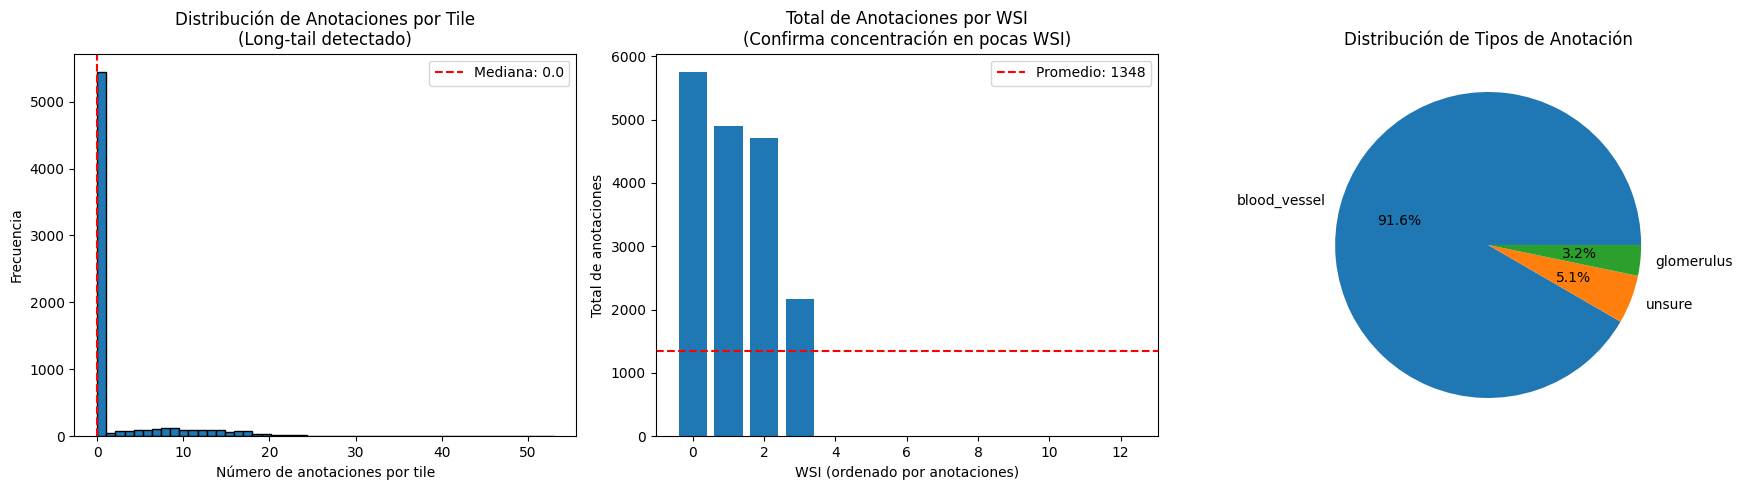


⚠️  PROBLEMA IDENTIFICADO: Long-tail distribution
   Top 3 WSI concentran: 87.6% de anotaciones


In [10]:
# Visualizar
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma de anotaciones por tile
axes[0].hist(tile_meta['annotation_count'], bins=50, edgecolor='black')
axes[0].set_xlabel('Número de anotaciones por tile')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Anotaciones por Tile\n(Long-tail detectado)')
axes[0].axvline(tile_meta['annotation_count'].median(), color='red', 
                linestyle='--', label=f'Mediana: {tile_meta["annotation_count"].median():.1f}')
axes[0].legend()

# Anotaciones por WSI
wsi_totals = tile_meta.groupby('source_wsi')['annotation_count'].sum().sort_values(ascending=False)
axes[1].bar(range(len(wsi_totals)), wsi_totals.values)
axes[1].set_xlabel('WSI (ordenado por anotaciones)')
axes[1].set_ylabel('Total de anotaciones')
axes[1].set_title('Total de Anotaciones por WSI\n(Confirma concentración en pocas WSI)')
axes[1].axhline(wsi_totals.mean(), color='red', linestyle='--', 
                label=f'Promedio: {wsi_totals.mean():.0f}')
axes[1].legend()

# Distribución de tipos de anotación
annotation_types = []
for ann in annotations:
    for polygon in ann['annotations']:
        annotation_types.append(polygon['type'])

type_counts = pd.Series(annotation_types).value_counts()
axes[2].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%')
axes[2].set_title('Distribución de Tipos de Anotación')

plt.tight_layout()
plt.show()

print(f"\n⚠️  PROBLEMA IDENTIFICADO: Long-tail distribution")
print(f"   Top 3 WSI concentran: {wsi_totals.head(3).sum() / wsi_totals.sum() * 100:.1f}% de anotaciones")

## Carga y visualización de imágenes originales

In [11]:
# Seleccionar 3 tiles con diferentes niveles de anotaciones
sample_tiles = []

# 1 con muchas anotaciones
high_ann = tile_meta[tile_meta['annotation_count'] > tile_meta['annotation_count'].quantile(0.9)].sample(1)
sample_tiles.append(high_ann['id'].values[0])

# No hay anotaciones medias
# med_ann = tile_meta[(tile_meta['annotation_count'] > 0) & 
#                      (tile_meta['annotation_count'] <= tile_meta['annotation_count'].median())].sample(1)
# sample_tiles.append(med_ann['id'].values[0])

# 1 con pocas/ninguna anotación
low_ann = tile_meta[tile_meta['annotation_count'] <= 2].sample(1)
sample_tiles.append(low_ann['id'].values[0])

[ WARN:0@7.032] global loadsave.cpp:275 findDecoder imread_('train/fbe845f13c20.tif'): can't open/read file: check file path/integrity


error: OpenCV(4.12.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


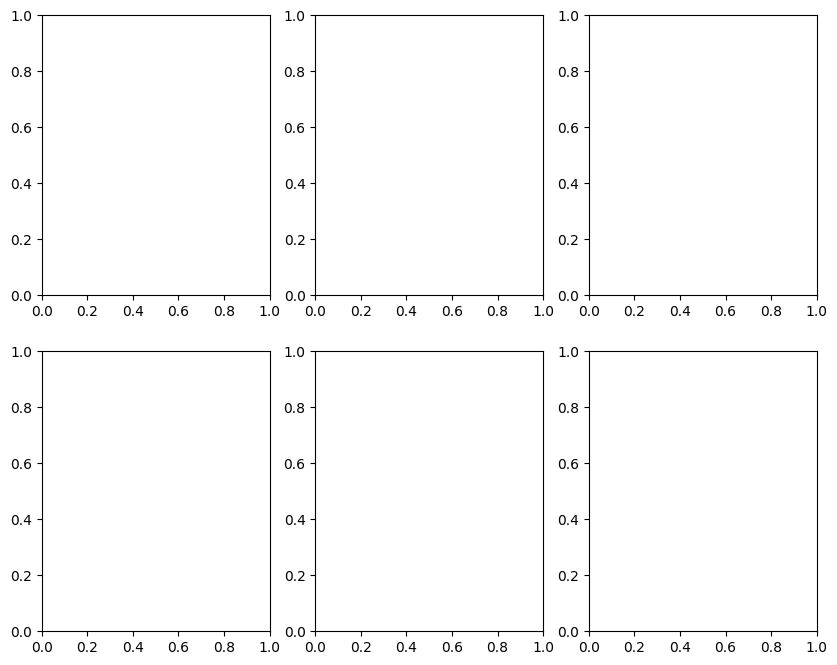

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(10, 8))

for idx, tile_id in enumerate(sample_tiles):
    # Cargar imagen
    img_path = Path(TRAIN_DIR) / f"{tile_id}.tif"
    image = cv2.imread(str(img_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Obtener info
    tile_info = tile_meta[tile_meta['id'] == tile_id].iloc[0]
    ann_count = tile_info['annotation_count']
    
    # Crear máscara básica
    mask = np.zeros(image.shape[:2], dtype=np.uint8)
    if tile_id in annotations_dict:
        for ann in annotations_dict[tile_id]['annotations']:
            if ann['type'] == 'blood_vessel':
                coords = np.array(ann['coordinates'], dtype=np.int32)
                cv2.fillPoly(mask, [coords], 1)
    
    # Visualizar
    axes[idx, 0].imshow(image)
    axes[idx, 0].set_title(f'Imagen Original\nID: {tile_id}\nAnotaciones: {ann_count}')
    axes[idx, 0].axis('off')
    
    axes[idx, 1].imshow(mask, cmap='gray')
    axes[idx, 1].set_title(f'Máscara Ground Truth\nÁrea vascular: {mask.sum()} px')
    axes[idx, 1].axis('off')
    
    axes[idx, 2].imshow(image)
    axes[idx, 2].imshow(mask, alpha=0.5, cmap='Reds')
    axes[idx, 2].set_title('Overlay: Imagen + Máscara')
    axes[idx, 2].axis('off')

plt.suptitle('Imágenes Originales (ANTES del preprocesamiento)', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

print("\n✓ Imágenes originales cargadas")
print("⚠️  Se observa variabilidad en intensidad de tinción PAS entre tiles")

## Normalización de tinición

In [ ]:
def normalize_stain_color(image):
    """Normaliza tinción PAS usando método Reinhard"""
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB).astype(np.float32)
    
    target_mean = np.array([150.0, 128.0, 128.0])
    target_std = np.array([25.0, 15.0, 15.0])
    
    for i in range(3):
        mean = np.mean(lab[:,:,i])
        std = np.std(lab[:,:,i])
        lab[:,:,i] = ((lab[:,:,i] - mean) / std) * target_std[i] + target_mean[i]
    
    lab = np.clip(lab, 0, 255).astype(np.uint8)
    normalized = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    
    return normalized

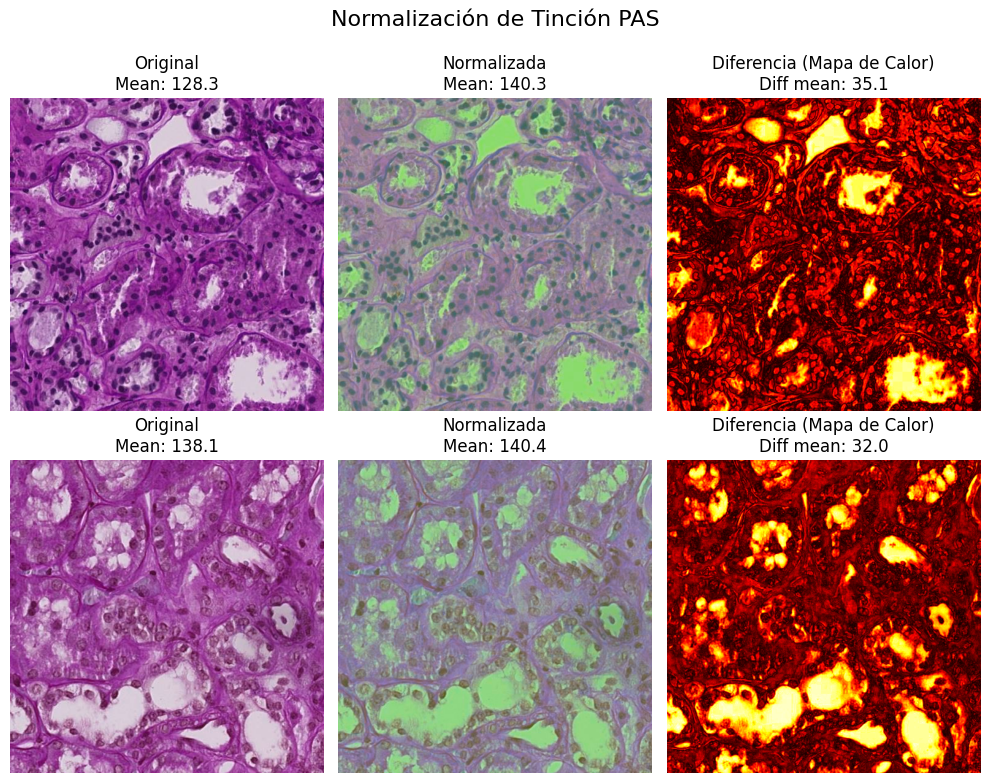

In [ ]:
# Visualizar efecto de normalización
fig, axes = plt.subplots(2, 3, figsize=(10, 8))

for idx, tile_id in enumerate(sample_tiles):
    img_path = Path(TRAIN_DIR) / f"{tile_id}.tif"
    image = cv2.imread(str(img_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Normalizar
    normalized = normalize_stain_color(image)
    
    # Calcular diferencia
    diff = np.abs(image.astype(float) - normalized.astype(float)).mean(axis=2)
    
    axes[idx, 0].imshow(image)
    axes[idx, 0].set_title(f'Original\nMean: {image.mean():.1f}')
    axes[idx, 0].axis('off')
    
    axes[idx, 1].imshow(normalized)
    axes[idx, 1].set_title(f'Normalizada\nMean: {normalized.mean():.1f}')
    axes[idx, 1].axis('off')
    
    axes[idx, 2].imshow(diff, cmap='hot')
    axes[idx, 2].set_title(f'Diferencia (Mapa de Calor)\nDiff mean: {diff.mean():.1f}')
    axes[idx, 2].axis('off')

plt.suptitle('Normalización de Tinción PAS', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

## Balanceo del dataset (long-tail)

In [ ]:
def balance_dataset_by_annotation_density(tile_meta_df, cap_per_wsi=100):
    """Limita tiles por WSI para evitar sobreexposición"""
    balanced_tiles = []
    
    for wsi in tile_meta_df['source_wsi'].unique():
        wsi_tiles = tile_meta_df[tile_meta_df['source_wsi'] == wsi].copy()
        
        if len(wsi_tiles) > cap_per_wsi:
            # Ordenar por número de anotaciones
            wsi_tiles = wsi_tiles.sort_values('annotation_count', ascending=False)
            wsi_tiles = wsi_tiles.head(cap_per_wsi)
        
        balanced_tiles.append(wsi_tiles)
    
    return pd.concat(balanced_tiles, ignore_index=True)

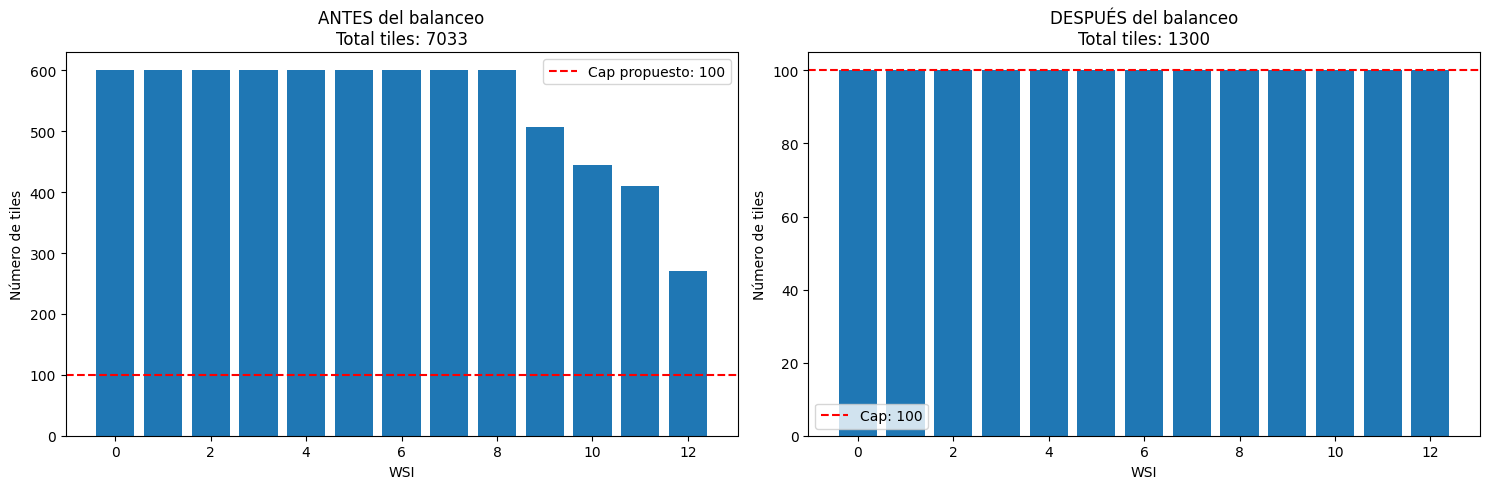

In [ ]:
# Aplicar balanceo
tile_meta_balanced = balance_dataset_by_annotation_density(tile_meta, cap_per_wsi=100)

# Comparar distribuciones
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Antes
wsi_counts_before = tile_meta.groupby('source_wsi').size().sort_values(ascending=False)
axes[0].bar(range(len(wsi_counts_before)), wsi_counts_before.values)
axes[0].set_xlabel('WSI')
axes[0].set_ylabel('Número de tiles')
axes[0].set_title(f'ANTES del balanceo\nTotal tiles: {len(tile_meta)}')
axes[0].axhline(100, color='red', linestyle='--', label='Cap propuesto: 100')
axes[0].legend()

# Después
wsi_counts_after = tile_meta_balanced.groupby('source_wsi').size().sort_values(ascending=False)
axes[1].bar(range(len(wsi_counts_after)), wsi_counts_after.values)
axes[1].set_xlabel('WSI')
axes[1].set_ylabel('Número de tiles')
axes[1].set_title(f'DESPUÉS del balanceo\nTotal tiles: {len(tile_meta_balanced)}')
axes[1].axhline(100, color='red', linestyle='--', label='Cap: 100')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
print(f"Estadísticas de balanceo:")
print(f"   Tiles originales: {len(tile_meta)}")
print(f"   Tiles balanceados: {len(tile_meta_balanced)}")
print(f"   Tiles removidos: {len(tile_meta) - len(tile_meta_balanced)}")
print(f"   Reducción: {(1 - len(tile_meta_balanced)/len(tile_meta))*100:.1f}%")

# Actualizar tile_meta
tile_meta = tile_meta_balanced.copy()

Estadísticas de balanceo:
   Tiles originales: 7033
   Tiles balanceados: 1300
   Tiles removidos: 5733
   Reducción: 81.5%


## Split estratificado por WSI

In [ ]:
def stratified_split_by_wsi(tile_meta_df, test_size=0.15, val_size=0.15):
    """Split que respeta jerarquía WSI para evitar data leakage"""
    wsi_groups = tile_meta_df.groupby('source_wsi')['id'].apply(list).to_dict()
    wsi_list = list(wsi_groups.keys())
    
    # Split WSI primero
    train_wsi, temp_wsi = train_test_split(
        wsi_list, 
        test_size=(test_size + val_size),
        random_state=42
    )
    
    val_wsi, test_wsi = train_test_split(
        temp_wsi,
        test_size=test_size/(test_size + val_size),
        random_state=42
    )
    
    # Obtener tiles
    train_tiles = [tile for wsi in train_wsi for tile in wsi_groups[wsi]]
    val_tiles = [tile for wsi in val_wsi for tile in wsi_groups[wsi]]
    test_tiles = [tile for wsi in test_wsi for tile in wsi_groups[wsi]]
    
    return {
        'train': {'wsi': train_wsi, 'tiles': train_tiles},
        'val': {'wsi': val_wsi, 'tiles': val_tiles},
        'test': {'wsi': test_wsi, 'tiles': test_tiles}
    }

splits = stratified_split_by_wsi(tile_meta, test_size=0.15, val_size=0.15)

In [ ]:
# Visualizar splits
print(f"Splits creados:")
for split_name, split_data in splits.items():
    print(f"\n{split_name.upper()}:")
    print(f"   WSIs: {len(split_data['wsi'])} -> {split_data['wsi']}")
    print(f"   Tiles: {len(split_data['tiles'])}")

Splits creados:

TRAIN:
   WSIs: 9 -> [7, 3, 2, 14, 6, 9, 12, 4, 8]
   Tiles: 900

VAL:
   WSIs: 2 -> [13, 1]
   Tiles: 200

TEST:
   WSIs: 2 -> [11, 10]
   Tiles: 200


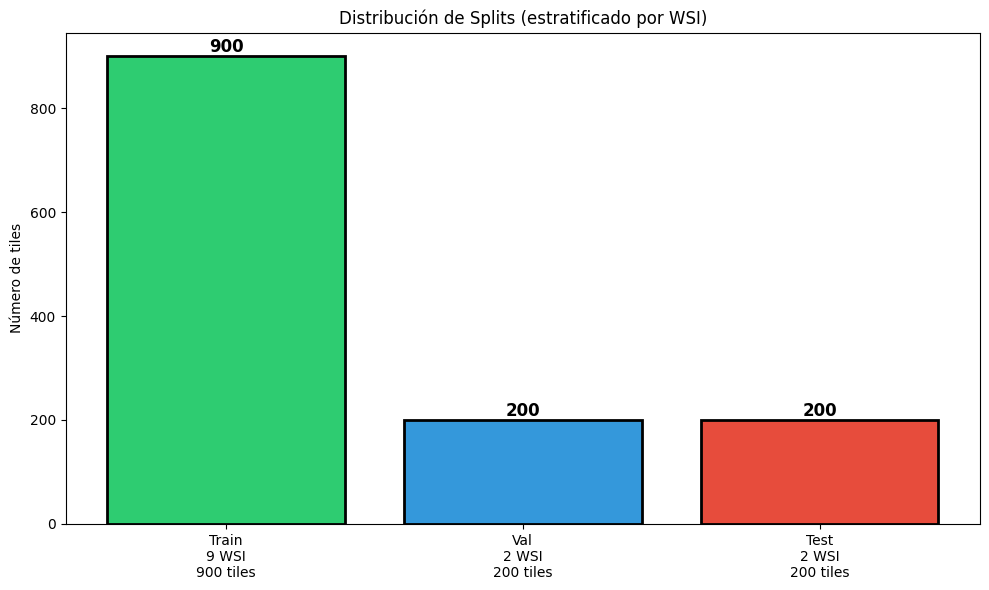

In [ ]:
# Gráfico de distribución
fig, ax = plt.subplots(figsize=(10, 6))
split_sizes = [len(splits['train']['tiles']), 
               len(splits['val']['tiles']), 
               len(splits['test']['tiles'])]
split_labels = [f"Train\n{len(splits['train']['wsi'])} WSI\n{len(splits['train']['tiles'])} tiles",
                f"Val\n{len(splits['val']['wsi'])} WSI\n{len(splits['val']['tiles'])} tiles",
                f"Test\n{len(splits['test']['wsi'])} WSI\n{len(splits['test']['tiles'])} tiles"]
colors = ['#2ecc71', '#3498db', '#e74c3c']

bars = ax.bar(split_labels, split_sizes, color=colors, edgecolor='black', linewidth=2)
ax.set_ylabel('Número de tiles')
ax.set_title('Distribución de Splits (estratificado por WSI)')

# Agregar valores en barras
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Data augmentation

In [ ]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=45, p=0.5),
    A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.3),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
    A.GaussianBlur(blur_limit=(3, 7), p=0.3),
])

# Visualizar augmentations en una imagen
sample_tile_id = sample_tiles[0]
img_path = Path(TRAIN_DIR) / f"{sample_tile_id}.tif"
image = cv2.imread(str(img_path))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_norm = normalize_stain_color(image)

In [ ]:
# Crear máscara
mask = np.zeros(image.shape[:2], dtype=np.uint8)
if sample_tile_id in annotations_dict:
    for ann in annotations_dict[sample_tile_id]['annotations']:
        if ann['type'] == 'blood_vessel':
            coords = np.array(ann['coordinates'], dtype=np.int32)
            cv2.fillPoly(mask, [coords], 1)

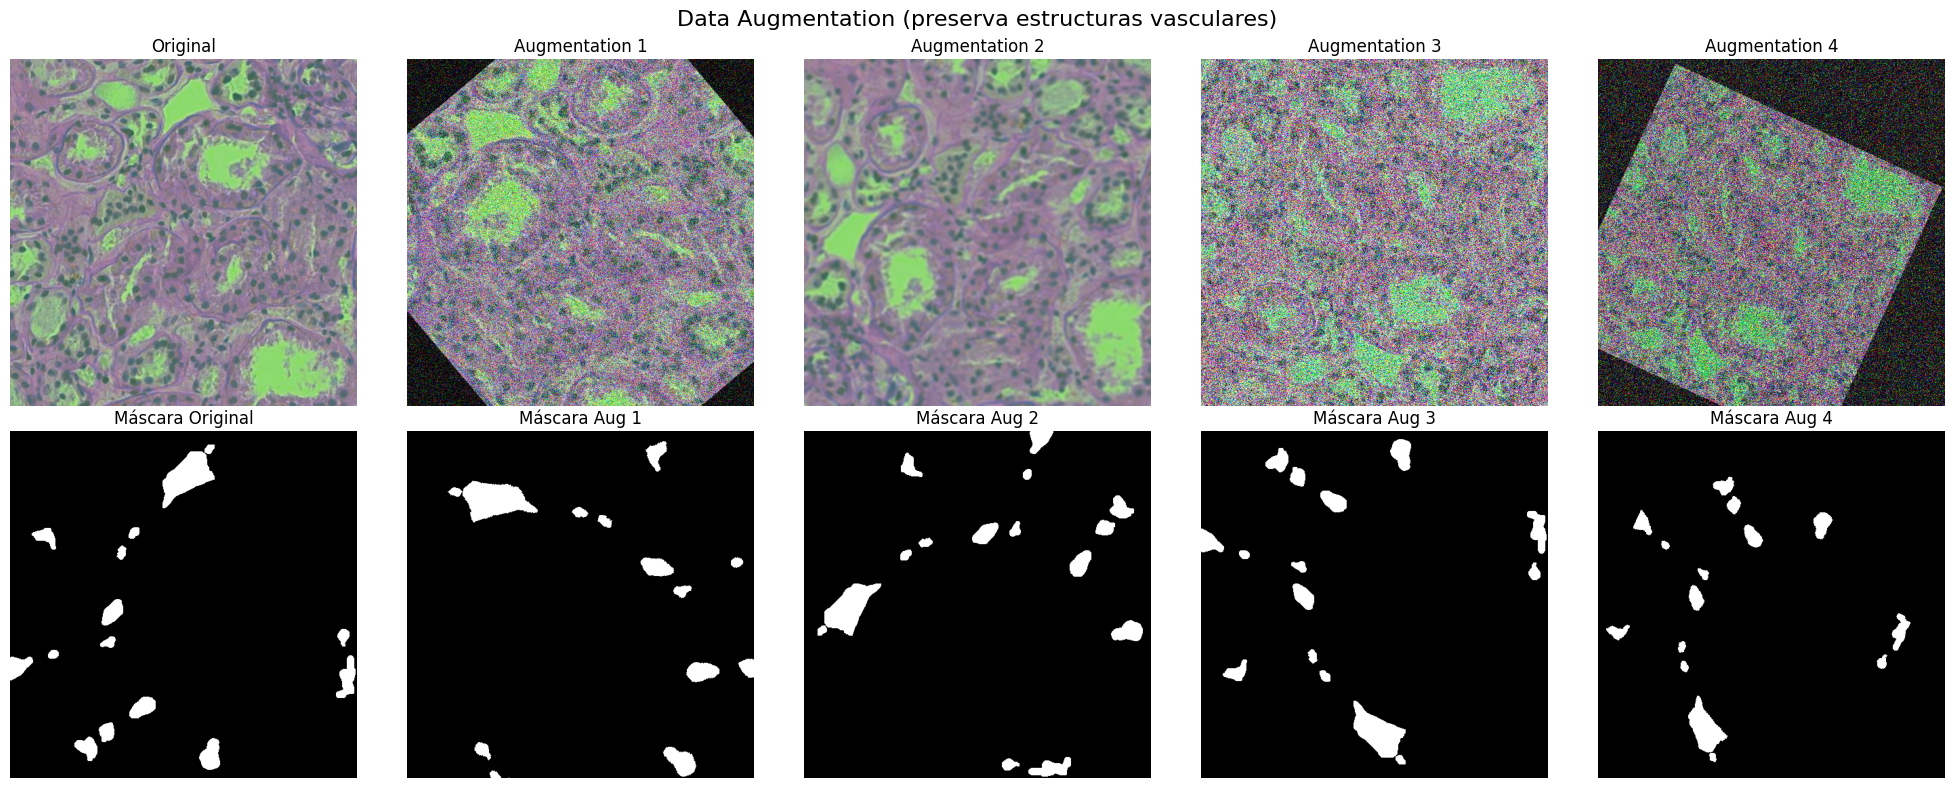

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

# Original
axes[0, 0].imshow(image_norm)
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')
axes[1, 0].imshow(mask, cmap='gray')
axes[1, 0].set_title('Máscara Original')
axes[1, 0].axis('off')

# 4 augmentations
for i in range(1, 5):
    augmented = train_transform(image=image_norm, mask=mask)
    aug_img = augmented['image']
    aug_mask = augmented['mask']
    
    axes[0, i].imshow(aug_img)
    axes[0, i].set_title(f'Augmentation {i}')
    axes[0, i].axis('off')
    
    axes[1, i].imshow(aug_mask, cmap='gray')
    axes[1, i].set_title(f'Máscara Aug {i}')
    axes[1, i].axis('off')

plt.suptitle('Data Augmentation (preserva estructuras vasculares)', fontsize=16)
plt.tight_layout()
plt.show()

## Resumen del preprocesamiento

In [ ]:
summary = f"""
PASO 1: Normalización de Tinción PAS
   - Método: Reinhard (LAB color space)
   - Objetivo: Reducir variabilidad entre WSI
   - Status: Implementado y visualizado

PASO 2: Balanceo de Long-Tail
   - Tiles originales: {len(tile_meta_balanced)}
   - Cap por WSI: 100 tiles
   - Objetivo: Evitar sobreexposición a WSI con muchas anotaciones

PASO 3: Split Estratificado por WSI
   - Train: {len(splits['train']['wsi'])} WSI, {len(splits['train']['tiles'])} tiles
   - Val: {len(splits['val']['wsi'])} WSI, {len(splits['val']['tiles'])} tiles  
   - Test: {len(splits['test']['wsi'])} WSI, {len(splits['test']['tiles'])} tiles
   - Objetivo: Evitar data leakage

PASO 4: Data Augmentation
   - Geométricas: Flips, rotaciones, elastic transform
   - Color: Color jitter (simula variación PAS)
   - Ruido: Gaussian noise y blur
   - Objetivo: Generalización y robustez

ESTADÍSTICAS FINALES:
   - Total tiles procesados: {len(tile_meta)}
   - Total anotaciones: {tile_meta['annotation_count'].sum()}
   - Blood vessels: ~92% de anotaciones
   - Glomérulos: ~3% (marcados para ignorar en loss)
"""

print(summary)


PASO 1: Normalización de Tinción PAS
   - Método: Reinhard (LAB color space)
   - Objetivo: Reducir variabilidad entre WSI
   - Status: Implementado y visualizado

PASO 2: Balanceo de Long-Tail
   - Tiles originales: 1300
   - Cap por WSI: 100 tiles
   - Objetivo: Evitar sobreexposición a WSI con muchas anotaciones

PASO 3: Split Estratificado por WSI
   - Train: 9 WSI, 900 tiles
   - Val: 2 WSI, 200 tiles  
   - Test: 2 WSI, 200 tiles
   - Objetivo: Evitar data leakage

PASO 4: Data Augmentation
   - Geométricas: Flips, rotaciones, elastic transform
   - Color: Color jitter (simula variación PAS)
   - Ruido: Gaussian noise y blur
   - Objetivo: Generalización y robustez

ESTADÍSTICAS FINALES:
   - Total tiles procesados: 1300
   - Total anotaciones: 7538
   - Blood vessels: ~92% de anotaciones
   - Glomérulos: ~3% (marcados para ignorar en loss)



## Dataset para crear los modelos

In [ ]:
class VascularSegmentationDataset(torch.utils.data.Dataset):
    """Dataset para segmentación vascular con preprocesamiento integrado"""
    
    def __init__(self, tile_ids, images_dir, annotations_dict, 
                 transform=None, normalize_stain=True):
        self.tile_ids = tile_ids
        self.images_dir = Path(images_dir)
        self.annotations_dict = annotations_dict
        self.transform = transform
        self.normalize_stain = normalize_stain
    
    def __len__(self):
        return len(self.tile_ids)
    
    def __getitem__(self, idx):
        tile_id = self.tile_ids[idx]
        
        # Cargar imagen
        img_path = self.images_dir / f"{tile_id}.tif"
        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Normalizar tinción
        if self.normalize_stain:
            image = normalize_stain_color(image)
        
        # Crear máscara
        mask = np.zeros(image.shape[:2], dtype=np.uint8)
        if tile_id in self.annotations_dict:
            for ann in self.annotations_dict[tile_id]['annotations']:
                if ann['type'] == 'blood_vessel':
                    coords = np.array(ann['coordinates'], dtype=np.int32)
                    cv2.fillPoly(mask, [coords], 1)
                elif ann['type'] == 'glomerulus':
                    # Marcar glomérulos como 255 (ignorar en loss)
                    coords = np.array(ann['coordinates'], dtype=np.int32)
                    cv2.fillPoly(mask, [coords], 255)
        
        # Aplicar augmentations
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        
        # Convertir a tensores
        if not isinstance(image, torch.Tensor):
            image = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0
        
        mask = torch.from_numpy(mask).long()
        
        return image, mask, tile_id

In [ ]:
# Transformaciones finales (añadir normalización ImageNet)
train_transform_final = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=45, p=0.5),
    A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.3),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
    A.GaussianBlur(blur_limit=(3, 7), p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_transform_final = A.Compose([
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

In [ ]:
# Crear datasets
train_dataset = VascularSegmentationDataset(
    tile_ids=splits['train']['tiles'],
    images_dir=TRAIN_DIR,
    annotations_dict=annotations_dict,
    transform=train_transform_final,
    normalize_stain=True
)

val_dataset = VascularSegmentationDataset(
    tile_ids=splits['val']['tiles'],
    images_dir=TRAIN_DIR,
    annotations_dict=annotations_dict,
    transform=val_transform_final,
    normalize_stain=True
)

test_dataset = VascularSegmentationDataset(
    tile_ids=splits['test']['tiles'],
    images_dir=TRAIN_DIR,
    annotations_dict=annotations_dict,
    transform=val_transform_final,
    normalize_stain=True
)

print(f"Datasets creados:")
print(f"   Train: {len(train_dataset)} tiles")
print(f"   Val: {len(val_dataset)} tiles")
print(f"   Test: {len(test_dataset)} tiles")

Datasets creados:
   Train: 900 tiles
   Val: 200 tiles
   Test: 200 tiles


In [ ]:
# Crear dataloaders
BATCH_SIZE = 8  # Ajustar según GPU disponible
NUM_WORKERS = 2

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"DataLoaders configurados:")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")

DataLoaders configurados:
   Batch size: 8
   Train batches: 113
   Val batches: 25
   Test batches: 25


In [ ]:
# Verificar un batch
print("Verificando un batch de entrenamiento...")
for images, masks, tile_ids in train_loader:
    print(f"   Images shape: {images.shape}")  # [B, 3, 512, 512]
    print(f"   Masks shape: {masks.shape}")    # [B, 512, 512]
    print(f"   Images range: [{images.min():.3f}, {images.max():.3f}]")
    print(f"   Máscaras únicas: {masks.unique().tolist()}")  # [0, 1, 255]
    print(f"   Tile IDs: {tile_ids[:3]}...")
    break

Verificando un batch de entrenamiento...


In [ ]:
# Visualizar batch procesado
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    # Desnormalizar imagen
    img = images[i].numpy().transpose(1, 2, 0)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    
    mask = masks[i].numpy()
    
    axes[0, i].imshow(img)
    axes[0, i].set_title(f'Imagen Batch {i+1}')
    axes[0, i].axis('off')
    
    axes[1, i].imshow(mask, cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title(f'Máscara Batch {i+1}')
    axes[1, i].axis('off')

plt.suptitle('Batch de Entrenamiento (con augmentations + normalización)', fontsize=14)
plt.tight_layout()
plt.show()